In [70]:
import pandas as pd
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt

In [15]:
df=pd.read_excel("../Datasets/WIID_19Dec2018.xlsx")

In [16]:
df

,id,country,c3,c2,year,gini_reported,q1,q2,q3,q4,...,median_usd,gdp_ppp_pc_usd2011,population,revision,quality,quality_score,source,source_detailed,source_comments,survey
0,1,Afghanistan,AFG,AF,2008,29.00,9.00,13.00,17.00,22.00,...,NaN,1298.0,27294031.0,New 2013,High,12,National statistical authority,European Commission and the Government of Afgh...,National Risk and Vulnerability Assessment,NaN
1,2,Albania,ALB,AL,1996,27.01,9.15,13.70,17.73,23.29,...,1982.0,4812.0,3092228.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
2,3,Albania,ALB,AL,2002,31.74,8.35,12.58,16.49,22.21,...,1902.0,6316.0,3119029.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
3,4,Albania,ALB,AL,2005,30.60,8.40,12.90,17.03,22.50,...,2217.0,7563.0,3079179.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
4,5,Albania,ALB,AL,2008,29.98,8.87,13.07,16.83,22.23,...,2385.0,9018.0,2991651.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11096,11097,Zimbabwe,ZWE,ZW,1995,70.30,1.58,3.64,6.34,11.08,...,NaN,2488.0,11320346.0,NaN,Low,13,World Bank,"Deininger and Squire, World Bank 2004",World Bank. Compilation,"Income, Consumption and Expenditure Survey"
11097,11098,Zimbabwe,ZWE,ZW,2011,42.30,NaN,NaN,NaN,NaN,...,NaN,1667.0,14386649.0,New 2013,High,11,National statistical authority,Zimbabwe National Statistics Agency 2011,Zimbabwe Poverty Profile Report,Poverty Income Consumption and Expenditure Sur...
11098,11099,Zimbabwe,ZWE,ZW,2011,37.00,NaN,NaN,NaN,NaN,...,NaN,1667.0,14386649.0,New 2013,High,11,National statistical authority,Zimbabwe National Statistics Agency 2011,Zimbabwe Poverty Profile Report,Poverty Income Consumption and Expenditure Sur...
11099,11100,Zimbabwe,ZWE,ZW,2011,39.00,NaN,NaN,NaN,NaN,...,NaN,1667.0,14386649.0,New 2013,High,11,National statistical authority,Zimbabwe National Statistics Agency 2011,Zimbabwe Poverty Profile Report,Poverty Income Consumption and Expenditure Sur...


# DATA CLEANING

In [17]:
df.columns

Index(['id', 'country', 'c3', 'c2', 'year', 'gini_reported', 'q1', 'q2', 'q3',
       'q4', 'q5', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'd8', 'd9', 'd10',
       'bottom5', 'top5', 'resource', 'resource_detailed', 'scale',
       'scale_detailed', 'sharing_unit', 'reference_unit', 'areacovr',
       'areacovr_detailed', 'popcovr', 'popcovr_detailed', 'region_un',
       'region_un_sub', 'region_wb', 'eu', 'oecd', 'incomegroup', 'mean',
       'median', 'currency', 'reference_period', 'exchangerate', 'mean_usd',
       'median_usd', 'gdp_ppp_pc_usd2011', 'population', 'revision', 'quality',
       'quality_score', 'source', 'source_detailed', 'source_comments',
       'survey'],
      dtype='object')

In [18]:
df.dtypes

id                      int64
country                object
c3                     object
c2                     object
year                    int64
gini_reported         float64
q1                    float64
q2                    float64
q3                    float64
q4                    float64
q5                    float64
d1                    float64
d2                    float64
d3                    float64
d4                    float64
d5                    float64
d6                    float64
d7                    float64
d8                    float64
d9                    float64
d10                   float64
bottom5               float64
top5                  float64
resource               object
resource_detailed      object
scale                  object
scale_detailed         object
sharing_unit           object
reference_unit         object
areacovr               object
areacovr_detailed      object
popcovr                object
popcovr_detailed       object
region_un 

In [19]:
df.isnull().sum()

id                       0
country                  0
c3                       0
c2                       8
year                     0
gini_reported           47
q1                    4004
q2                    4168
q3                    4142
q4                    4136
q5                    4003
d1                    4837
d2                    4843
d3                    4843
d4                    4843
d5                    4823
d6                    4818
d7                    4812
d8                    4815
d9                    4801
d10                   4763
bottom5               9506
top5                  8922
resource                 1
resource_detailed        0
scale                  505
scale_detailed         505
sharing_unit           502
reference_unit          35
areacovr                 0
areacovr_detailed        0
popcovr                  0
popcovr_detailed         0
region_un                0
region_un_sub            0
region_wb                0
eu                       0
o

In [20]:
df.resource.mode()

0    Income (net)
Name: resource, dtype: object

In [21]:
df['sharing_unit']=df['sharing_unit'].fillna('Household')

In [22]:
df.sharing_unit.unique()

array(['Household', 'Person', 'Family', 'Tax unit'], dtype=object)

In [23]:
df.c2 = df.c2.fillna('Unknown')
df.resource = df.resource.fillna('Unknown')                    
df.scale = df.scale.fillna('Per capita')                  
df['scale_detailed'] = df['scale_detailed'].fillna('Per capita')         
df['sharing_unit'] = df['sharing_unit'].fillna('Household')          
df['reference_unit'] = df['reference_unit'].fillna('Person')          

In [24]:
df.q1=df.q1.fillna(6.13)
df.q2=df.q2.fillna(11.0)
df.q3=df.q3.fillna(15.72)
df.q4=df.q4.fillna(22.06)
df.q5=df.q5.fillna(44.5)

In [25]:
df.d1=df.d1.fillna(2.24)
df.d2=df.d2.fillna(3.81)
df.d3=df.d3.fillna(4.92)
df.d4=df.d4.fillna(6.0)
df.d5=df.d5.fillna(7.165)
df.d6=df.d6.fillna(8.45)
df.d7=df.d7.fillna(10.0)
df.d8=df.d8.fillna(11.99)
df.d9=df.d9.fillna(15.43)
df.d10=df.d10.fillna(29.18)

In [26]:
df = df.dropna(subset=['gini_reported'])

In [27]:
df.dtypes

id                      int64
country                object
c3                     object
c2                     object
year                    int64
gini_reported         float64
q1                    float64
q2                    float64
q3                    float64
q4                    float64
q5                    float64
d1                    float64
d2                    float64
d3                    float64
d4                    float64
d5                    float64
d6                    float64
d7                    float64
d8                    float64
d9                    float64
d10                   float64
bottom5               float64
top5                  float64
resource               object
resource_detailed      object
scale                  object
scale_detailed         object
sharing_unit           object
reference_unit         object
areacovr               object
areacovr_detailed      object
popcovr                object
popcovr_detailed       object
region_un 

In [28]:
df.isnull().sum()

id                       0
country                  0
c3                       0
c2                       0
year                     0
gini_reported            0
q1                       0
q2                       0
q3                       0
q4                       0
q5                       0
d1                       0
d2                       0
d3                       0
d4                       0
d5                       0
d6                       0
d7                       0
d8                       0
d9                       0
d10                      0
bottom5               9468
top5                  8884
resource                 0
resource_detailed        0
scale                    0
scale_detailed           0
sharing_unit             0
reference_unit           0
areacovr                 0
areacovr_detailed        0
popcovr                  0
popcovr_detailed         0
region_un                0
region_un_sub            0
region_wb                0
eu                       0
o

In [29]:
df

,id,country,c3,c2,year,gini_reported,q1,q2,q3,q4,...,median_usd,gdp_ppp_pc_usd2011,population,revision,quality,quality_score,source,source_detailed,source_comments,survey
0,1,Afghanistan,AFG,AF,2008,29.00,9.00,13.00,17.00,22.00,...,NaN,1298.0,27294031.0,New 2013,High,12,National statistical authority,European Commission and the Government of Afgh...,National Risk and Vulnerability Assessment,NaN
1,2,Albania,ALB,AL,1996,27.01,9.15,13.70,17.73,23.29,...,1982.0,4812.0,3092228.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
2,3,Albania,ALB,AL,2002,31.74,8.35,12.58,16.49,22.21,...,1902.0,6316.0,3119029.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
3,4,Albania,ALB,AL,2005,30.60,8.40,12.90,17.03,22.50,...,2217.0,7563.0,3079179.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
4,5,Albania,ALB,AL,2008,29.98,8.87,13.07,16.83,22.23,...,2385.0,9018.0,2991651.0,New 2018,Average,13,World Bank,World Bank 2018,PovcalNet,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11096,11097,Zimbabwe,ZWE,ZW,1995,70.30,1.58,3.64,6.34,11.08,...,NaN,2488.0,11320346.0,NaN,Low,13,World Bank,"Deininger and Squire, World Bank 2004",World Bank. Compilation,"Income, Consumption and Expenditure Survey"
11097,11098,Zimbabwe,ZWE,ZW,2011,42.30,6.13,11.00,15.72,22.06,...,NaN,1667.0,14386649.0,New 2013,High,11,National statistical authority,Zimbabwe National Statistics Agency 2011,Zimbabwe Poverty Profile Report,Poverty Income Consumption and Expenditure Sur...
11098,11099,Zimbabwe,ZWE,ZW,2011,37.00,6.13,11.00,15.72,22.06,...,NaN,1667.0,14386649.0,New 2013,High,11,National statistical authority,Zimbabwe National Statistics Agency 2011,Zimbabwe Poverty Profile Report,Poverty Income Consumption and Expenditure Sur...
11099,11100,Zimbabwe,ZWE,ZW,2011,39.00,6.13,11.00,15.72,22.06,...,NaN,1667.0,14386649.0,New 2013,High,11,National statistical authority,Zimbabwe National Statistics Agency 2011,Zimbabwe Poverty Profile Report,Poverty Income Consumption and Expenditure Sur...


# GLOBAL INEQUALITY DISTRIBUTION

## Income inequility distributed across countries

In [30]:
a=df.groupby('country')['gini_reported'].mean().sort_values(ascending=False)
a

country
South Africa      62.780213
Namibia           61.782500
Lesotho           58.855455
Belize            57.700000
Eswatini          57.177500
                    ...    
Yugoslavia        27.182143
Soviet Union      27.170588
Andorra           26.810000
Slovakia          26.796905
Czechoslovakia    20.671875
Name: gini_reported, Length: 187, dtype: float64

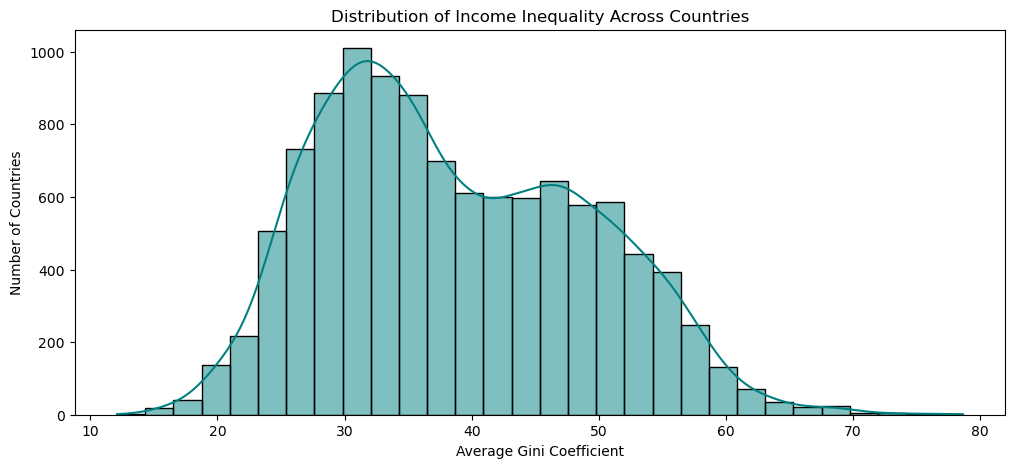

In [31]:
plt.figure(figsize=(12,5))
sb.histplot(df.gini_reported, bins=30, kde=True,color='Teal')
plt.title("Distribution of Income Inequality Across Countries")
plt.xlabel("Average Gini Coefficient")
plt.ylabel("Number of Countries")
plt.show()

#### As we study the above histplot, we get to know that maximum number of countries are having gini report near to 30. And the gini report of all the other countries varies from 20 to 65. 

## Countries having Highest and Lowest inequility levels

In [32]:
df.groupby('country')['gini_reported'].mean().nlargest()

country
South Africa    62.780213
Namibia         61.782500
Lesotho         58.855455
Belize          57.700000
Eswatini        57.177500
Name: gini_reported, dtype: float64

#### South Africa and Namibia are the countries having highest inequality levels followed by Lesotho and Belize.

In [33]:
df.groupby('country')['gini_reported'].mean().nsmallest()

country
Czechoslovakia    20.671875
Slovakia          26.796905
Andorra           26.810000
Soviet Union      27.170588
Yugoslavia        27.182143
Name: gini_reported, dtype: float64

#### Czechoslovakia and Slovakia have very low inequality levels followed by Andorra and Soviet Union. 

## Variation of Gini coefficient distributed globally

In [34]:
df.gini_reported.describe()

count    11054.000000
mean        38.648382
std         10.444241
min         12.100000
25%         30.400000
50%         37.000000
75%         46.800000
max         78.600000
Name: gini_reported, dtype: float64

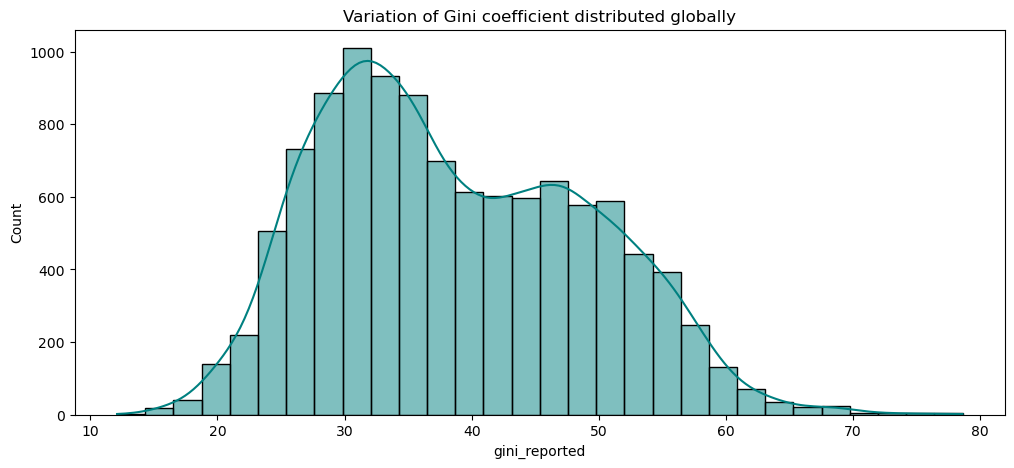

In [35]:
plt.figure(figsize=(12,5))
sb.histplot(df.gini_reported, bins=30, kde=True,color='Teal')
plt.title("Variation of Gini coefficient distributed globally")
plt.show()

# REGIONAL INEQUALITY DISTRIBUTION

## Variation of Income inequility across regions

In [36]:
df.region_un.unique()

array(['Asia', 'Europe', 'Africa', 'Americas', 'Oceania'], dtype=object)

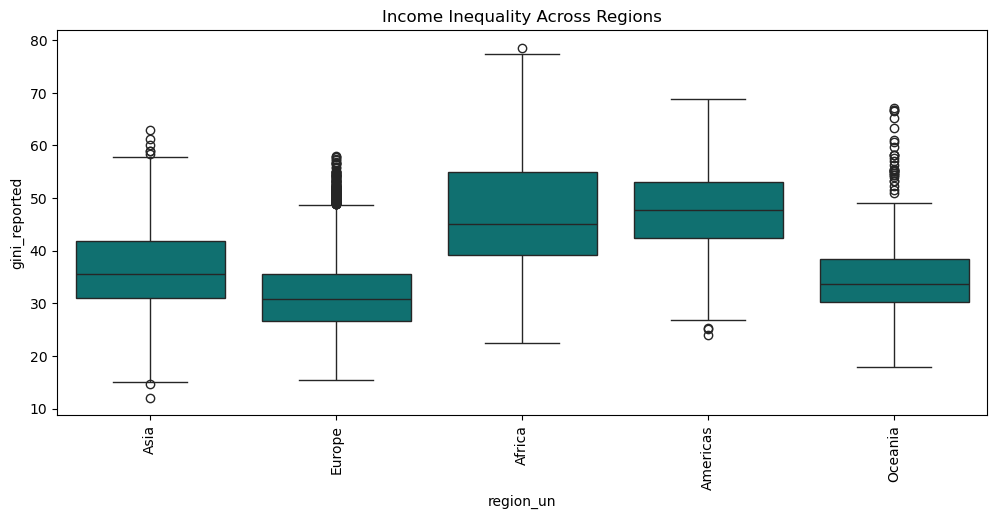

In [37]:
plt.figure(figsize=(12,5))
sb.boxplot(x=df.region_un, y=df.gini_reported,color='Teal')
plt.xticks(rotation=90)
plt.title("Income Inequality Across Regions")
plt.show()

#### The box plot confirms strong regional disparities in income inequality, with Africa and the Americas showing higher and more variable inequality, while Europe remains the most equal. Asia and Oceania fall in between, displaying moderate but diverse inequality levels.

## Region having highest average inequality level

In [38]:
df.groupby('region_un')['gini_reported'].mean().nlargest()

region_un
Africa      47.377500
Americas    47.128023
Asia        36.502831
Oceania     35.497077
Europe      31.910684
Name: gini_reported, dtype: float64

## Region having lowest average inequality level

In [39]:
df.groupby('region_un')['gini_reported'].mean().nsmallest()

region_un
Europe      31.910684
Oceania     35.497077
Asia        36.502831
Americas    47.128023
Africa      47.377500
Name: gini_reported, dtype: float64

## Are there noticeable regional patterns in Income distribution

In [40]:
df.groupby('region_un')['gini_reported'].describe()

,count,mean,std,min,25%,50%,75%,max
region_un,,,,,,,,
Africa,628.0,47.377500,10.947515,22.4,39.28,45.15,55.000,78.6
Americas,3531.0,47.128023,7.879501,24.0,42.40,47.80,53.000,68.9
Asia,2130.0,36.502831,7.805065,12.1,31.00,35.50,41.815,62.9
Europe,4416.0,31.910684,7.297039,15.5,26.70,30.90,35.500,58.0
Oceania,349.0,35.497077,9.454273,18.0,30.20,33.60,38.500,67.2


## Regional patterns in Income Distribution

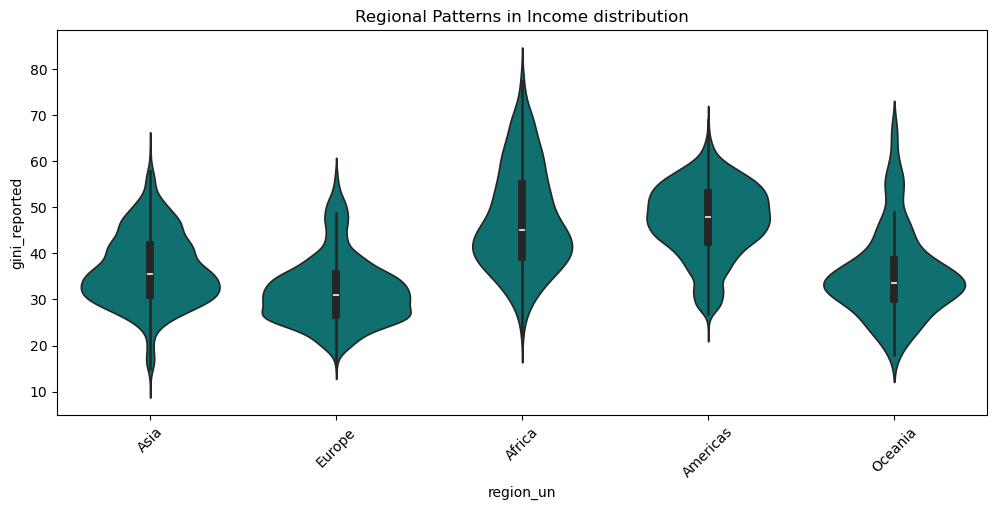

In [41]:
plt.figure(figsize=(12,5))
sb.violinplot(x=df.region_un,y=df.gini_reported,color='Teal')
plt.title("Regional Patterns in Income distribution")
plt.xticks(rotation=45)
plt.show()

#### The violin plot highlights strong regional differences in income inequality, with Africa and the Americas showing higher inequality, while Europe remains the most equal. Asia and Oceania display mixed patterns, indicating diverse economic structures within these regions.

# ECONOMIC DEVELOPMENT VS INEQUALITY

## Relationship between GDP per capita and Income inequality

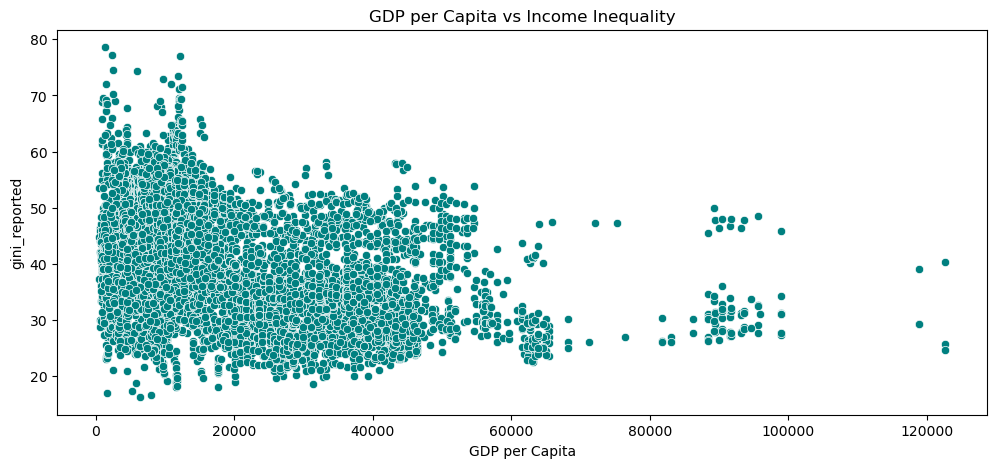

In [42]:
plt.figure(figsize=(12,5))
sb.scatterplot(x=df.gdp_ppp_pc_usd2011,y=df.gini_reported,color='Teal')
plt.title("GDP per Capita vs Income Inequality")
plt.xlabel("GDP per Capita")
plt.show()

#### The scatter plot shows a general negative relationship between GDP per capita and income inequality, meaning richer countries tend to be more equal. However, the wide spread at lower income levels and some exceptions among richer countries indicate that economic growth alone does not ensure equality.

## Do countries with higher GDP tend to have lower inequality

In [43]:
gdp=df.groupby('country')[['gdp_ppp_pc_usd2011','gini_reported']].mean().sort_values(by='gdp_ppp_pc_usd2011',ascending=False).head(10).reset_index()
gdp

,country,gdp_ppp_pc_usd2011,gini_reported
0,Qatar,120734.500000,31.383333
1,Luxembourg,88277.032258,31.125100
2,Norway,58187.460870,29.741180
3,Switzerland,53912.194030,31.863067
4,Singapore,48784.409091,43.735185
5,Saudi Arabia,47334.000000,48.600000
6,United States,46178.994253,39.874085
7,Hong Kong (China),43540.458333,46.690000
8,Ireland,43294.704545,35.970680
9,Oman,42121.000000,30.700000


##  Do countries with higher GDP tend to have lower inequality?
#### Countries with higher GDP per capita do not always have lower income inequality. While some high-income countries exhibit more equal income distribution, there are several exceptions where wealthy nations still experience significant inequality. Overall, the relationship between GDP and inequality is weak and not strictly negative.

# INCOME GROUP COMPARISION

In [44]:
df.incomegroup.unique()

array(['Low income', 'Upper middle income', 'High income',
       'Lower middle income'], dtype=object)

## Inequality variation between income groups

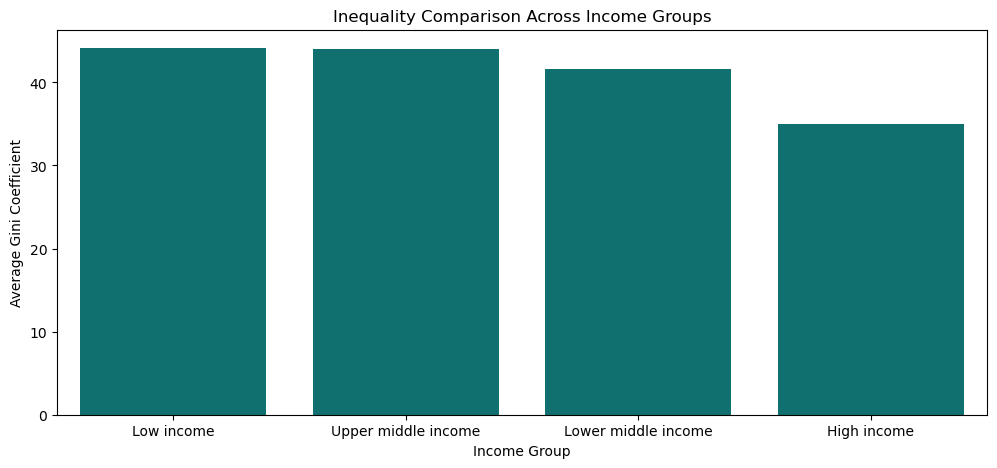

In [45]:
income_avg = df.groupby('incomegroup')['gini_reported'].mean().reset_index().sort_values(by='gini_reported', ascending=False)

plt.figure(figsize=(12,5))
sb.barplot(x=income_avg.incomegroup, y=income_avg.gini_reported,color='Teal')
plt.title("Inequality Comparison Across Income Groups")
plt.xlabel("Income Group")
plt.ylabel("Average Gini Coefficient")
plt.show()

#### The bar chart shows that wealthier nations generally have lower average inequality, as high-income countries have the lowest Gini coefficient. However, the similarity between low-income and upper-middle-income groups indicates that this relationship is not perfectly consistent.

## Incomegroup vise inequality distribution

In [46]:
df.groupby('incomegroup')['gini_reported'].mean().nlargest()

incomegroup
Low income             44.133236
Upper middle income    43.989934
Lower middle income    41.650689
High income            34.945038
Name: gini_reported, dtype: float64

<Axes: xlabel='incomegroup'>

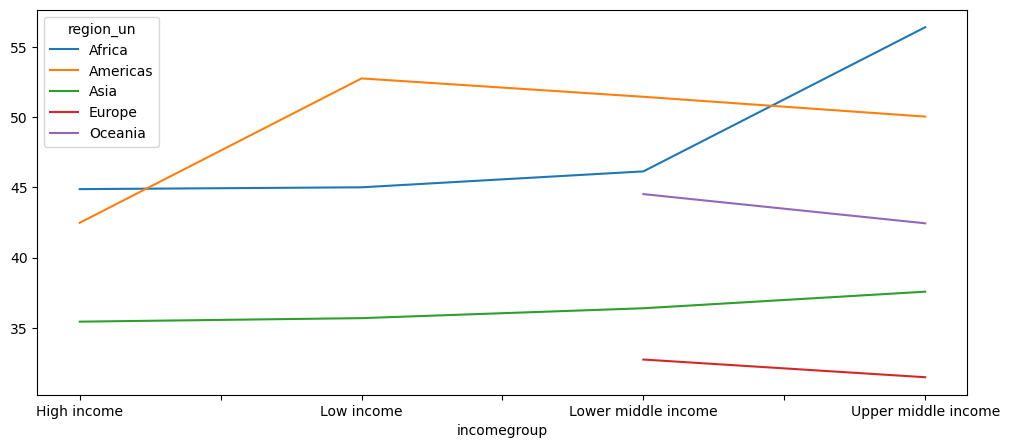

In [47]:
group_trend = df.groupby(['incomegroup','region_un'])['gini_reported'].mean().unstack()
group_trend.plot(figsize=(12,5))

## Incomegroup distribution

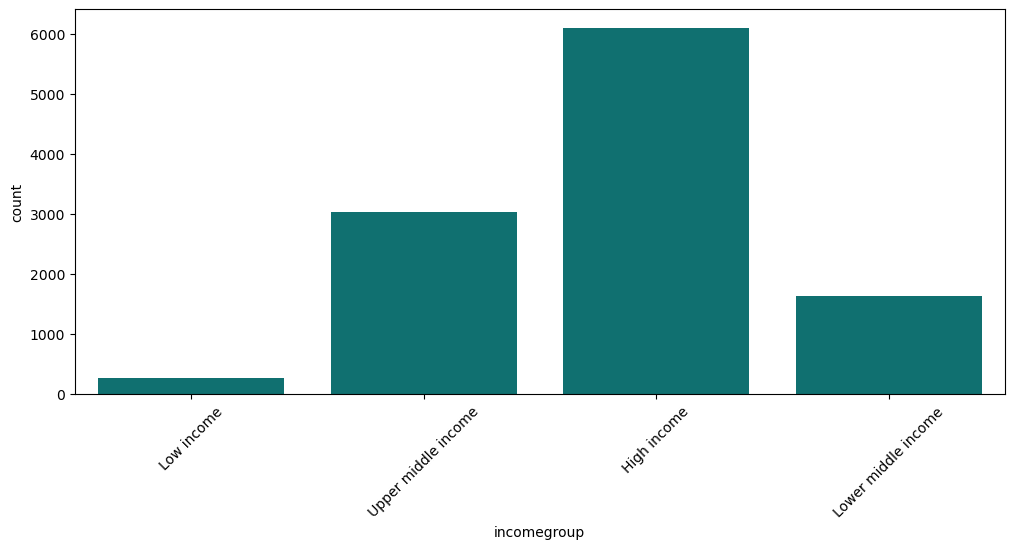

In [48]:
plt.figure(figsize=(12,5))
sb.countplot(x=df.incomegroup,color='Teal')
plt.xticks(rotation=45)
plt.show()

#### Maximun count is in the High Income group and very low count in low income which shows a slow positive development.

## Region wise distribution of incomegroups

In [49]:
pd.crosstab(index=df.incomegroup,columns=df.region_un)

region_un,Africa,Americas,Asia,Europe,Oceania
incomegroup,,,,,
High income,6,1440,603,3735,324
Low income,240,5,30,0,0
Lower middle income,279,417,812,124,9
Upper middle income,103,1669,685,557,16


## Do wealthier nations consistently maintain lower inequality levels?

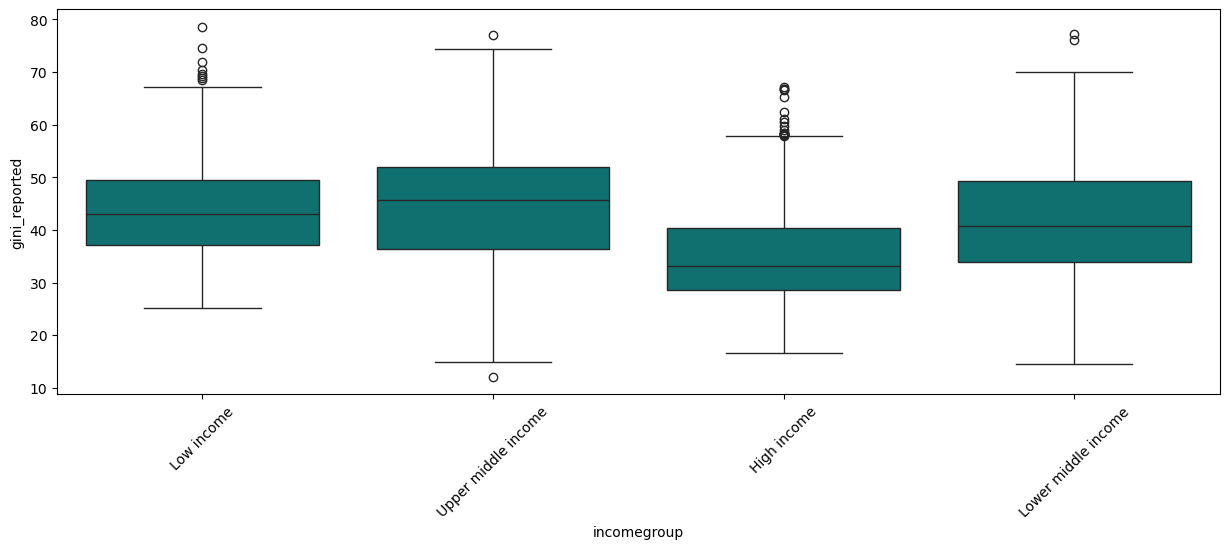

In [50]:
plt.figure(figsize=(15,5))
sb.boxplot(x=df.incomegroup,y=df.gini_reported,color='Teal')
plt.xticks(rotation=45)
plt.show()

#### The box plot shows that high-income countries tend to have lower income inequality, while low-income countries often experience higher and more uneven distribution of wealth

# How stable are inequality levels across different income groups?
#### Inequality levels are more stable in high-income countries, while low-income and middle-income countries exhibit greater variability and less stability in income distribution. This indicates that developed economies tend to maintain more consistent inequality levels over time.

# INEQUALITY TREND ANALYSIS

## Which country demonstrate more equal income distribution

In [73]:
equal_countries = a.sort_values(by='a').head(10)

plt.figure(figsize=(10,4))
plt.scatter(equal_countries['gini_reported'], equal_countries['country'],color='Teal',edgecolor='black')
plt.title("Top 10 Countries with Most Equal Income Distribution")
plt.xlabel("Gini Coefficient")
plt.ylabel("Country")
plt.show()

TypeError: Series.sort_values() got an unexpected keyword argument 'by'

##  Is there any relationship between GDP per capita and Income inequality?

In [58]:
cg=df.groupby('country')[['gdp_ppp_pc_usd2011','gini_reported']].sum().sort_values(by='gdp_ppp_pc_usd2011',ascending=False).head(10).reset_index()
cg

,country,gdp_ppp_pc_usd2011,gini_reported
0,Canada,8645035.0,12663.41
1,Luxembourg,8209764.0,3112.51
2,United States,8035145.0,12201.47
3,Germany,7821919.0,9036.53
4,Finland,6790349.0,7474.37
5,Norway,6691558.0,4788.33
6,Denmark,5163186.0,5498.32
7,Netherlands,4575284.0,4719.94
8,United Kingdom,4518750.0,7439.96
9,Italy,3876092.0,5188.54


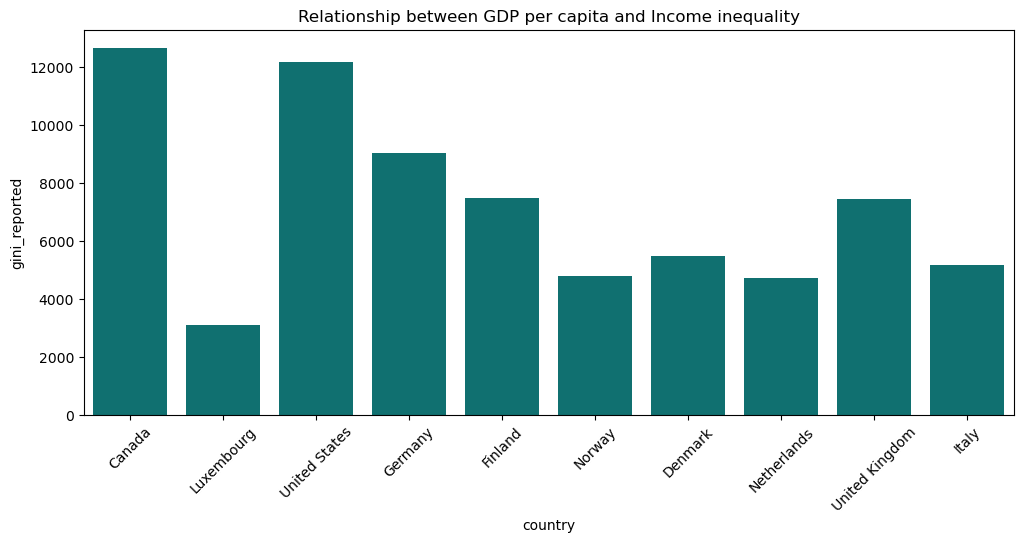

In [59]:
plt.figure(figsize=(12,5))
sb.barplot(x=cg.country,y=cg.gini_reported,color='Teal')
plt.title("Relationship between GDP per capita and Income inequality")
plt.xticks(rotation=45)
plt.show()



#### The graph compares GDP per capita with income inequality
#### No strict linear relationship i.e higher GDP doesn’t always mean lower inequality



## Which income group shows the greatest inequality variation

In [60]:
variation = df.groupby('incomegroup')['gini_reported'].std().reset_index().sort_values(by='gini_reported', ascending=False)

highest_variation = variation.iloc[0]

print("Income group with highest inequality variation:\n")
print(highest_variation)

Income group with highest inequality variation:

incomegroup      Upper middle income
gini_reported              10.796899
Name: 3, dtype: object


## How stable are inequality levels across diff income groups

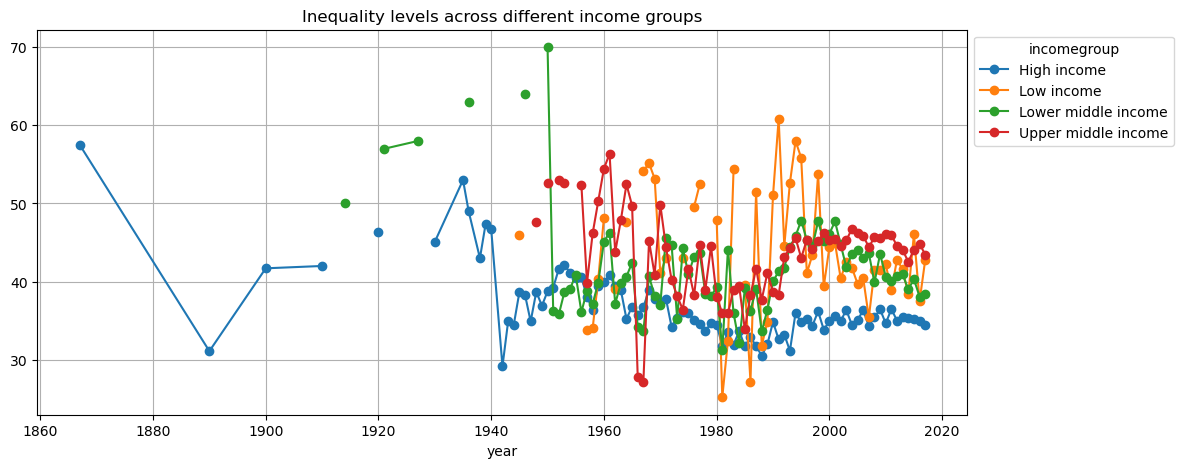

In [61]:
regional_trend = df.groupby(['year','incomegroup'])['gini_reported'].mean().unstack()
regional_trend.plot(figsize=(12,5),marker='o')
plt.title("Inequality levels across different income groups")
plt.grid(True)
plt.legend(title='incomegroup',bbox_to_anchor=(1.0,1.0))

#### Economic development is strongly linked with inequality—countries tend to experience high inequality during early growth stages, which gradually reduces and stabilizes as they become high-income economies

In [62]:
group_trend = df.groupby(['incomegroup','region_un'])['gini_reported'].mean().unstack()
group_trend

region_un,Africa,Americas,Asia,Europe,Oceania
incomegroup,,,,,
High income,44.878333,42.484903,35.450282,31.944212,34.903117
Low income,45.007667,52.754000,35.701000,NaN,NaN
Lower middle income,46.140502,51.447098,36.403559,32.755968,44.523333
Upper middle income,56.395728,50.038095,37.582175,31.497684,42.447500


# COUNTRY LEVEL INEQUALITY ANALYSIS

## Which countries consistently show high inequality levels

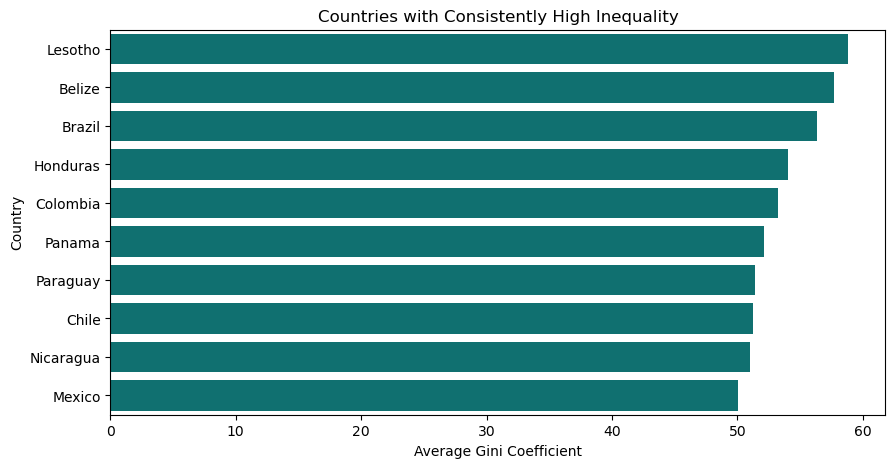

In [63]:
country_gini = df.groupby('country')['gini_reported'].mean().reset_index()
country_std = df.groupby('country')['gini_reported'].std().reset_index()

country_stats = pd.merge(country_gini, country_std, on='country')
country_stats.columns = ['country', 'avg_gini', 'std_gini']

high_inequality = country_stats[(country_stats['avg_gini'] > 45) & (country_stats['std_gini'] < 5)]
high_inequality = high_inequality.sort_values(by='avg_gini', ascending=False)

top_countries = high_inequality.head(10)

plt.figure(figsize=(10,5))
sb.barplot(x=top_countries.avg_gini, y=top_countries.country,color='Teal')
plt.title("Countries with Consistently High Inequality")
plt.xlabel("Average Gini Coefficient")
plt.ylabel("Country")
plt.show()

#### Countries like Lesotho, Belize, Brazil show consistently very high inequality (above 55)
#### Most countries in the list have Gini values above 50, indicating persistent inequality
#### Many are from Latin America and Africa, suggesting regional inequality patterns

## Which Countries show the highest and lowest inequality levels

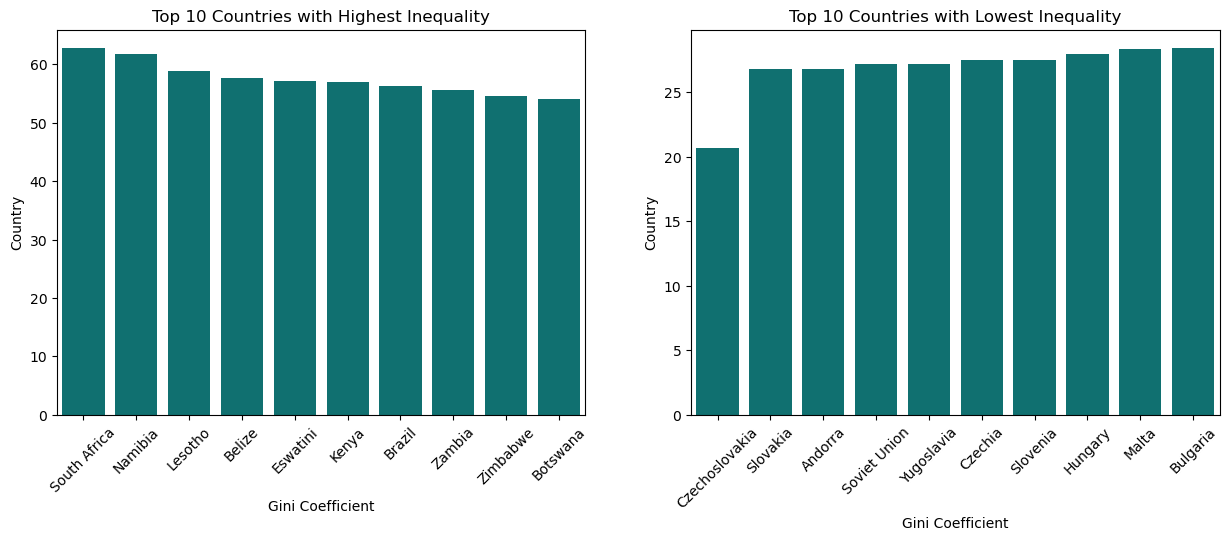

In [64]:
top10 = country_gini.sort_values(by='gini_reported', ascending=False).head(10)

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sb.barplot(x=top10.country, y=top10.gini_reported,color='Teal')
plt.title("Top 10 Countries with Highest Inequality")
plt.xlabel("Gini Coefficient")
plt.ylabel("Country")
plt.xticks(rotation=45)

bottom10 = country_gini.sort_values(by='gini_reported').head(10)

plt.subplot(1,2,2)
sb.barplot(x=bottom10.country, y=bottom10.gini_reported,color='Teal')
plt.title("Top 10 Countries with Lowest Inequality")
plt.xlabel("Gini Coefficient")
plt.ylabel("Country")
plt.xticks(rotation=45)

plt.show()

#### High inequality countries are mostly developing regions
#### Low inequality countries are mostly European nations
#### Economic development and policies play a major role in income distribution.

# POPULATION & INEQUALITY TREND ANALYSIS

## How has income inequality changed over time globally

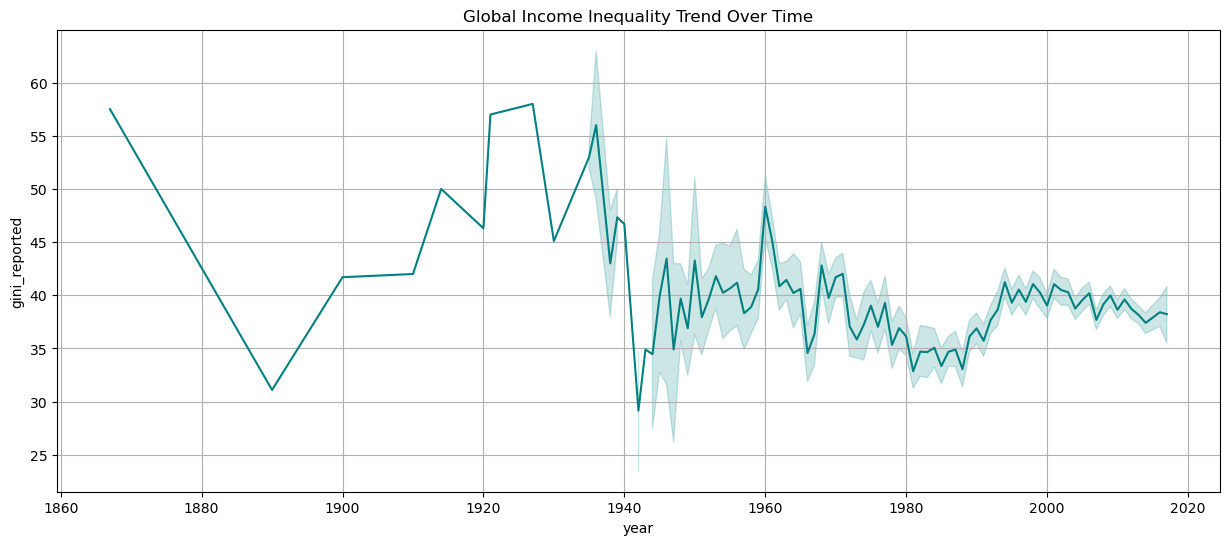

In [65]:
plt.figure(figsize=(15,6))
sb.lineplot(x=df.year,y=df.gini_reported,color='Teal')
plt.title("Global Income Inequality Trend Over Time")
plt.grid(True)
plt.show()

## Are there periods where inequality increased or decreased significantly

#### At the starting year there was high income inequality but as we move on further we can see there is a lot of fluctuation in its levels and currently it shows inequality levels near 35-40.

## Is there any relationship between a country's population size and inequality level

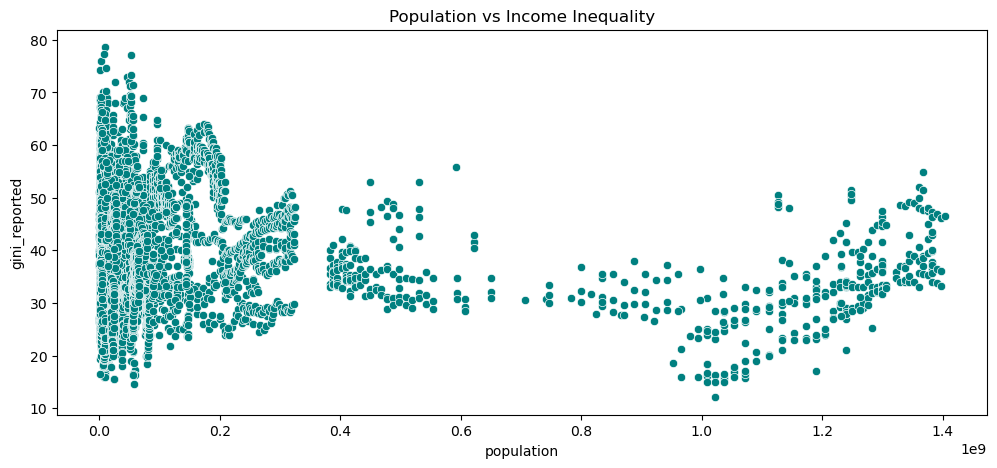

In [66]:
plt.figure(figsize=(12,5))
sb.scatterplot(x='population',y='gini_reported',data=df,color='Teal')
plt.title("Population vs Income Inequality")
plt.show()

##  Do highly populated countries tend to have higher inequality

#### As per the above plot we can see that highly populated countries do not necessarily tend to have higher inequality. Inequality and Population as such do not have any dependency it mostly depend on economic growth.